<a href="https://colab.research.google.com/github/puneetbisarwal25/Deep-Learning-Basic/blob/main/variational_autoencoder_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import the main PyTorch library for deep learning operations
import torch
# Import NumPy for numerical operations, especially array manipulations
import numpy as np
# Import neural network modules from PyTorch, like layers (e.g., Linear), activation functions
import torch.nn as nn
# Import the Adam optimizer, a popular algorithm for training neural networks
from torch.optim import Adam
# Import Matplotlib for creating plots and visualizations
import matplotlib.pyplot as plt
# Import the MNIST dataset from torchvision, a common dataset for image classification
from torchvision.datasets import MNIST
# Import DataLoader for efficient loading and batching of datasets
from torch.utils.data import DataLoader
# Import transforms from torchvision for image preprocessing
import torchvision.transforms as transforms
# Import ImageGrid from mpl_toolkits for arranging images in a grid format
from mpl_toolkits.axes_grid1 import ImageGrid
# Import utilities for saving images and creating image grids from torchvision
from torchvision.utils import save_image, make_grid

In [ ]:
# Define a transformation to apply to each datapoint (image)
# transforms.ToTensor() converts a PIL Image or numpy.ndarray to a PyTorch FloatTensor
# and scales the image pixel values to the range [0.0, 1.0]
transform = transforms.Compose([transforms.ToTensor()])

# Define the path where the dataset will be downloaded and stored
path = '~/datasets'
# Download and load the MNIST training dataset, applying the defined transform
train_dataset = MNIST(path, transform=transform, download=True)
# Download and load the MNIST test dataset, applying the defined transform
test_dataset  = MNIST(path, transform=transform, download=True)

# Define the batch size for training and testing
batch_size = 100
# Create a DataLoader for the training dataset, enabling batching and shuffling
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
# Create a DataLoader for the test dataset, enabling batching without shuffling
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Set the device to GPU if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

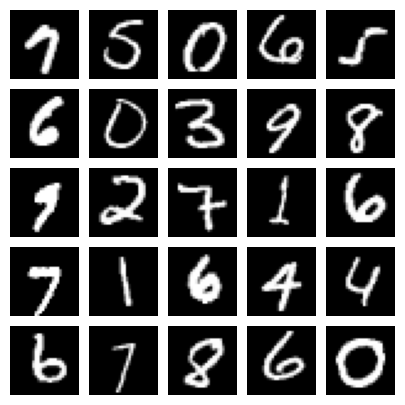

In [ ]:
# Get an iterator for the training data loader
dataiter = iter(train_loader)
# Get the next batch of images and labels from the iterator
image = next(dataiter)

# Define the number of sample images to visualize
num_samples = 25
# Extract the first 'num_samples' images from the batch (assuming batch[0] is the images and batch[0][i,0] selects the single channel image)
sample_images = [image[0][i,0] for i in range(num_samples)]

# Create a new figure for plotting with a specific size
fig = plt.figure(figsize=(5, 5))
# Create an ImageGrid to arrange the sample images in a 5x5 grid
grid = ImageGrid(fig, 111, nrows_ncols=(5, 5), axes_pad=0.1)

# Iterate through the grid axes and sample images
for ax, im in zip(grid, sample_images):
    # Display each image in grayscale
    ax.imshow(im, cmap='gray')
    # Turn off the axis for a cleaner look
    ax.axis('off')

# Display the plot with all sample images
plt.show()

In [ ]:
# Define the Encoder class, inheriting from nn.Module for neural network functionalities
class Encoder(nn.Module):

    # Constructor to initialize the encoder layers
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=256):
        # Call the constructor of the parent class (nn.Module)
        super(Encoder, self).__init__()

        # Define the first linear layer: input_dim -> hidden_dim
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        # Define the second linear layer: hidden_dim -> hidden_dim
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        # Define the linear layer to output the mean of the latent space
        self.mean = nn.Linear(hidden_dim, latent_dim)
        # Define the linear layer to output the log variance of the latent space
        self.var = nn.Linear (hidden_dim, latent_dim)
        # Define the LeakyReLU activation function with a negative slope of 0.2
        self.LeakyReLU = nn.LeakyReLU(0.2)
        # Initialize a training flag (though often handled by model.train()/model.eval())
        self.training = True

    # Define the forward pass of the encoder
    def forward(self, x):
        # Apply the first linear layer followed by LeakyReLU activation
        x = self.LeakyReLU(self.linear1(x))
        # Apply the second linear layer followed by LeakyReLU activation
        x = self.LeakyReLU(self.linear2(x))

        # Compute the mean vector from the hidden layer output
        mean = self.mean(x)
        # Compute the log variance vector from the hidden layer output
        log_var = self.var(x)
        # Return the mean and log variance
        return mean, log_var

In [ ]:
# Define the Decoder class, inheriting from nn.Module for neural network functionalities
class Decoder(nn.Module):

    # Constructor to initialize the decoder layers
    def __init__(self, output_dim=784, hidden_dim=512, latent_dim=256):
        # Call the constructor of the parent class (nn.Module)
        super(Decoder, self).__init__()

        # Define the first linear layer: latent_dim -> hidden_dim (in decoding order)
        self.linear2 = nn.Linear(latent_dim, hidden_dim)
        # Define the second linear layer: hidden_dim -> hidden_dim
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        # Define the output linear layer: hidden_dim -> output_dim (reconstructed image)
        self.output = nn.Linear(hidden_dim, output_dim)
        # Define the LeakyReLU activation function with a negative slope of 0.2
        self.LeakyReLU = nn.LeakyReLU(0.2)

    # Define the forward pass of the decoder
    def forward(self, x):
        # Apply the first linear layer (from latent space) followed by LeakyReLU activation
        x = self.LeakyReLU(self.linear2(x))
        # Apply the second linear layer followed by LeakyReLU activation
        x = self.LeakyReLU(self.linear1(x))

        # Apply the output linear layer and then a sigmoid activation to produce pixel values between 0 and 1
        x_hat = torch.sigmoid(self.output(x))
        # Return the reconstructed input (image)
        return x_hat

In [ ]:
# Define the VAE (Variational Autoencoder) class, inheriting from nn.Module
class VAE(nn.Module):

    # Constructor to initialize the VAE components
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device=device):
        # Call the constructor of the parent class (nn.Module)
        super(VAE, self).__init__()

        # Define the encoder part as a sequential block of layers
        self.encoder = nn.Sequential(
            # First linear layer: input_dim -> hidden_dim
            nn.Linear(input_dim, hidden_dim),
            # LeakyReLU activation function
            nn.LeakyReLU(0.2),
            # Second linear layer: hidden_dim -> latent_dim (intermediate latent representation)
            nn.Linear(hidden_dim, latent_dim),
            # LeakyReLU activation function
            nn.LeakyReLU(0.2)
            )

        # Define linear layers to output the mean and log variance from the encoder's output
        # This maps the latent_dim (intermediate) to the final 2-dimensional latent space
        self.mean_layer = nn.Linear(latent_dim, 2)
        self.logvar_layer = nn.Linear(latent_dim, 2)

        # Define the decoder part as a sequential block of layers
        self.decoder = nn.Sequential(
            # First linear layer: 2 (latent space dimensions) -> latent_dim (intermediate latent representation)
            nn.Linear(2, latent_dim),
            # LeakyReLU activation function
            nn.LeakyReLU(0.2),
            # Second linear layer: latent_dim -> hidden_dim
            nn.Linear(latent_dim, hidden_dim),
            # LeakyReLU activation function
            nn.LeakyReLU(0.2),
            # Output linear layer: hidden_dim -> input_dim (reconstructed image)
            nn.Linear(hidden_dim, input_dim),
            # Sigmoid activation to squash pixel values between 0 and 1
            nn.Sigmoid()
            )

    # Method to encode the input 'x' into mean and log variance
    def encode(self, x):
        # Pass the input through the encoder sequential block
        x = self.encoder(x)
        # Compute the mean and log variance using their respective layers
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        # Return the mean and log variance
        return mean, logvar

    # Method to perform the reparameterization trick
    def reparameterization(self, mean, var):
        # Sample epsilon from a standard normal distribution (same shape as var)
        epsilon = torch.randn_like(var).to(device)
        # Calculate the latent vector 'z' using the reparameterization trick
        z = mean + var*epsilon
        # Return the sampled latent vector 'z'
        return z

    # Method to decode a latent vector 'x' back into the input space
    def decode(self, x):
        # Pass the latent vector through the decoder sequential block
        return self.decoder(x)

    # Define the full forward pass of the VAE
    def forward(self, x):
        # Encode the input 'x' to get the mean and log variance of the latent distribution
        mean, log_var = self.encode(x)
        # Apply the reparameterization trick using the mean and the standard deviation (exp(0.5 * log_var))
        z = self.reparameterization(mean, torch.exp(0.5 * log_var))
        # Decode the sampled latent vector 'z' to reconstruct the input 'x'
        x_hat = self.decode(z)
        # Return the reconstructed input, the mean, and the log variance
        return x_hat, mean, log_var

In [ ]:
# Instantiate the VAE model and move it to the specified device (GPU/CPU)
model = VAE().to(device)
# Initialize the Adam optimizer with the model's parameters and a learning rate of 0.001
optimizer = Adam(model.parameters(), lr=1e-3)

In [ ]:
# Define the loss function for the VAE
def loss_function(x, x_hat, mean, log_var):
    # Calculate the reproduction loss (reconstruction loss) using binary cross-entropy
    # 'reduction='sum'' sums the loss over all elements in the batch
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    # Calculate the Kullback-Leibler Divergence (KLD) loss
    # This term regularizes the latent space distribution to be close to a standard normal distribution
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    # The total VAE loss is the sum of the reproduction loss and the KLD loss
    return reproduction_loss + KLD

In [ ]:
# Define the training function for the VAE model
def train(model, optimizer, epochs, device, x_dim=784):
    # Set the model to training mode
    model.train()
    # Loop through the specified number of training epochs
    for epoch in range(epochs):
        # Initialize the overall loss for the current epoch
        overall_loss = 0
        # Iterate through batches of data from the training loader
        # '_' is used to ignore the labels, as VAE is an unsupervised model
        for batch_idx, (x, _) in enumerate(train_loader):
            # Reshape the input images from (batch_size, 1, 28, 28) to (batch_size, 784)
            # and move them to the specified device (GPU/CPU)
            x = x.view(batch_size, x_dim).to(device)

            # Zero out the gradients from the previous iteration
            optimizer.zero_grad()

            # Perform the forward pass through the VAE model
            # This returns the reconstructed input, mean, and log variance
            x_hat, mean, log_var = model(x)
            # Calculate the VAE loss using the custom loss function
            loss = loss_function(x, x_hat, mean, log_var)

            # Accumulate the loss for the current epoch
            overall_loss += loss.item()

            # Perform backpropagation to compute gradients
            loss.backward()
            # Update the model's parameters using the optimizer
            optimizer.step()

        # Print the average loss for the current epoch
        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))
    # Return the final overall loss (from the last epoch)
    return overall_loss

In [ ]:
# Call the train function to start the training process for 50 epochs
# Pass the VAE model, optimizer, number of epochs, and device
train(model, optimizer, epochs=50, device=device)

	Epoch 1 	Average Loss:  180.07574696434162
	Epoch 2 	Average Loss:  162.2099096149833
	Epoch 3 	Average Loss:  158.29884631938648
	Epoch 4 	Average Loss:  156.2253949290484
	Epoch 5 	Average Loss:  154.25001389033807
	Epoch 6 	Average Loss:  152.53217144133453
	Epoch 7 	Average Loss:  151.5303626323821
	Epoch 8 	Average Loss:  150.39873438152128
	Epoch 9 	Average Loss:  149.70531590737167
	Epoch 10 	Average Loss:  149.0453990863679
	Epoch 11 	Average Loss:  148.49494660697516
	Epoch 12 	Average Loss:  148.11010310152338
	Epoch 13 	Average Loss:  147.58979665001564
	Epoch 14 	Average Loss:  147.28316458420284
	Epoch 15 	Average Loss:  146.7874820338585
	Epoch 16 	Average Loss:  146.54393134064586
	Epoch 17 	Average Loss:  146.30478758542884
	Epoch 18 	Average Loss:  146.06248601184265
	Epoch 19 	Average Loss:  145.73502054204926
	Epoch 20 	Average Loss:  145.49747756677797
	Epoch 21 	Average Loss:  145.11921128312812
	Epoch 22 	Average Loss:  145.0675632075595
	Epoch 23 	Average Loss: 

8454589.317382812

In [ ]:
# Define a function to generate a single digit from a given mean and variance in the latent space
def generate_digit(mean, var):
    # Create a tensor representing the 2D latent space coordinate [mean, var]
    # and move it to the specified device
    z_sample = torch.tensor([[mean, var]], dtype=torch.float).to(device)
    # Decode the latent sample 'z_sample' back into an image using the VAE decoder
    x_decoded = model.decode(z_sample)
    # Detach the tensor from the computation graph, move it to CPU, and reshape it into a 28x28 image
    digit = x_decoded.detach().cpu().reshape(28, 28)
    # Set the title of the plot to show the mean and variance values used
    plt.title(f'[{mean},{var}]')
    # Display the generated digit in grayscale
    plt.imshow(digit, cmap='gray')
    # Turn off the axes for a cleaner image display
    plt.axis('off')
    # Show the plot
    plt.show()

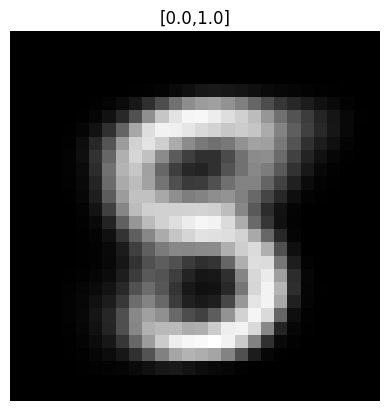

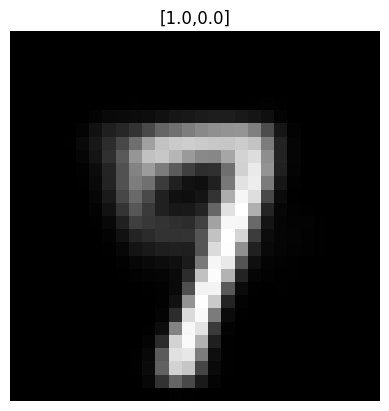

(None, None)

In [ ]:
# Call the generate_digit function twice with different mean and variance values
# to visualize two distinct generated digits
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

In [ ]:
# Define a function to visualize the 2D latent space of the VAE
def plot_latent_space(model, scale=5.0, n=25, digit_size=28, figsize=15):
    # Create an empty NumPy array to hold the grid of generated digits
    # The size will be (digit_size * n) by (digit_size * n)
    figure = np.zeros((digit_size * n, digit_size * n))

    # Construct a grid of x (mean) and y (variance) values for the latent space
    # grid_x samples 'n' points evenly between -scale and +scale
    grid_x = np.linspace(-scale, scale, n)
    # grid_y samples 'n' points evenly between -scale and +scale, then reverses the order
    grid_y = np.linspace(-scale, scale, n)[::-1]

    # Iterate through each point in the 2D grid
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            # Create a tensor for the current latent space coordinate [xi, yi]
            # and move it to the specified device
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            # Decode the latent sample into an image using the VAE's decoder
            x_decoded = model.decode(z_sample)
            # Detach the tensor, move to CPU, and reshape it into a 28x28 digit image
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            # Place the generated digit into the corresponding position in the 'figure' array
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    # Create a new figure for plotting with a specified size
    plt.figure(figsize=(figsize, figsize))
    # Set the title of the plot
    plt.title('VAE Latent Space Visualization')
    # Calculate the starting range for x-axis tick labels
    start_range = digit_size // 2
    # Calculate the ending range for x-axis tick labels
    end_range = n * digit_size + start_range
    # Create an array of pixel positions for the tick marks
    pixel_range = np.arange(start_range, end_range, digit_size)
    # Round the latent space coordinates for display as x-axis labels
    sample_range_x = np.round(grid_x, 1)
    # Round the latent space coordinates for display as y-axis labels
    sample_range_y = np.round(grid_y, 1)
    # Set the x-axis tick marks and labels
    plt.xticks(pixel_range, sample_range_x)
    # Set the y-axis tick marks and labels
    plt.yticks(pixel_range, sample_range_y)
    # Set the x-axis label
    plt.xlabel("mean, z [0]")
    # Set the y-axis label
    plt.ylabel("var, z [1]")
    # Display the complete figure of generated digits in grayscale
    plt.imshow(figure, cmap="Greys_r")
    # Show the plot
    plt.show()

/tmp/ipykernel_3171/3629231675.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit


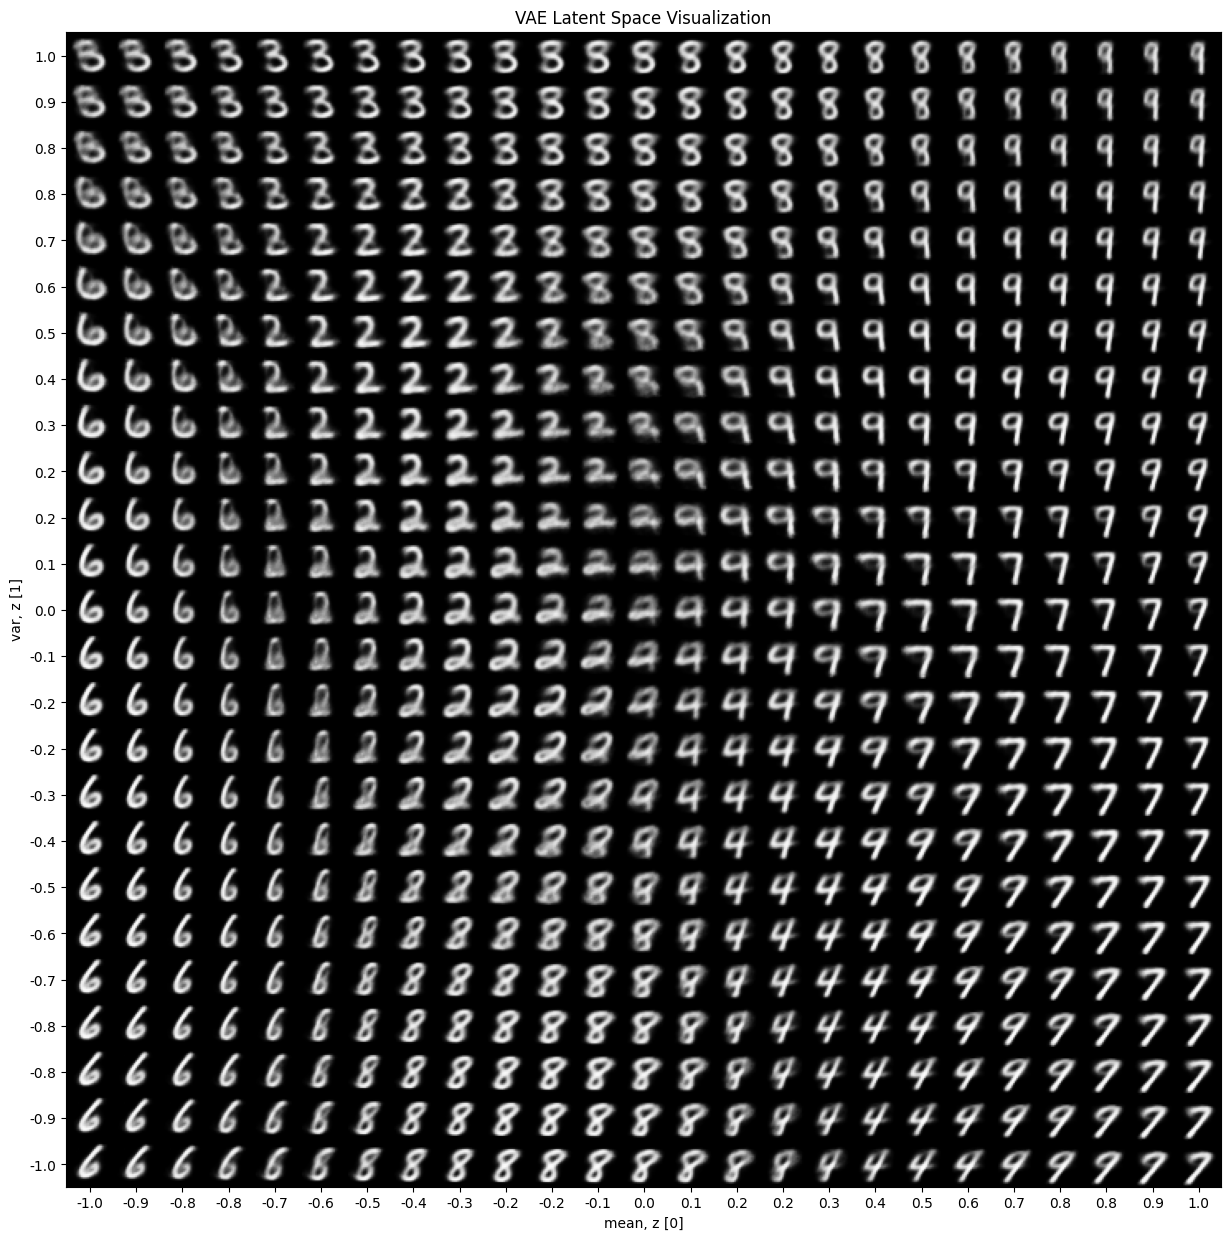

In [ ]:
# Call the plot_latent_space function to visualize the latent space with a scale of 1.0
# This generates a grid of digits corresponding to a smaller region of the latent space
plot_latent_space(model, scale=1.0)

/tmp/ipykernel_3171/3629231675.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit


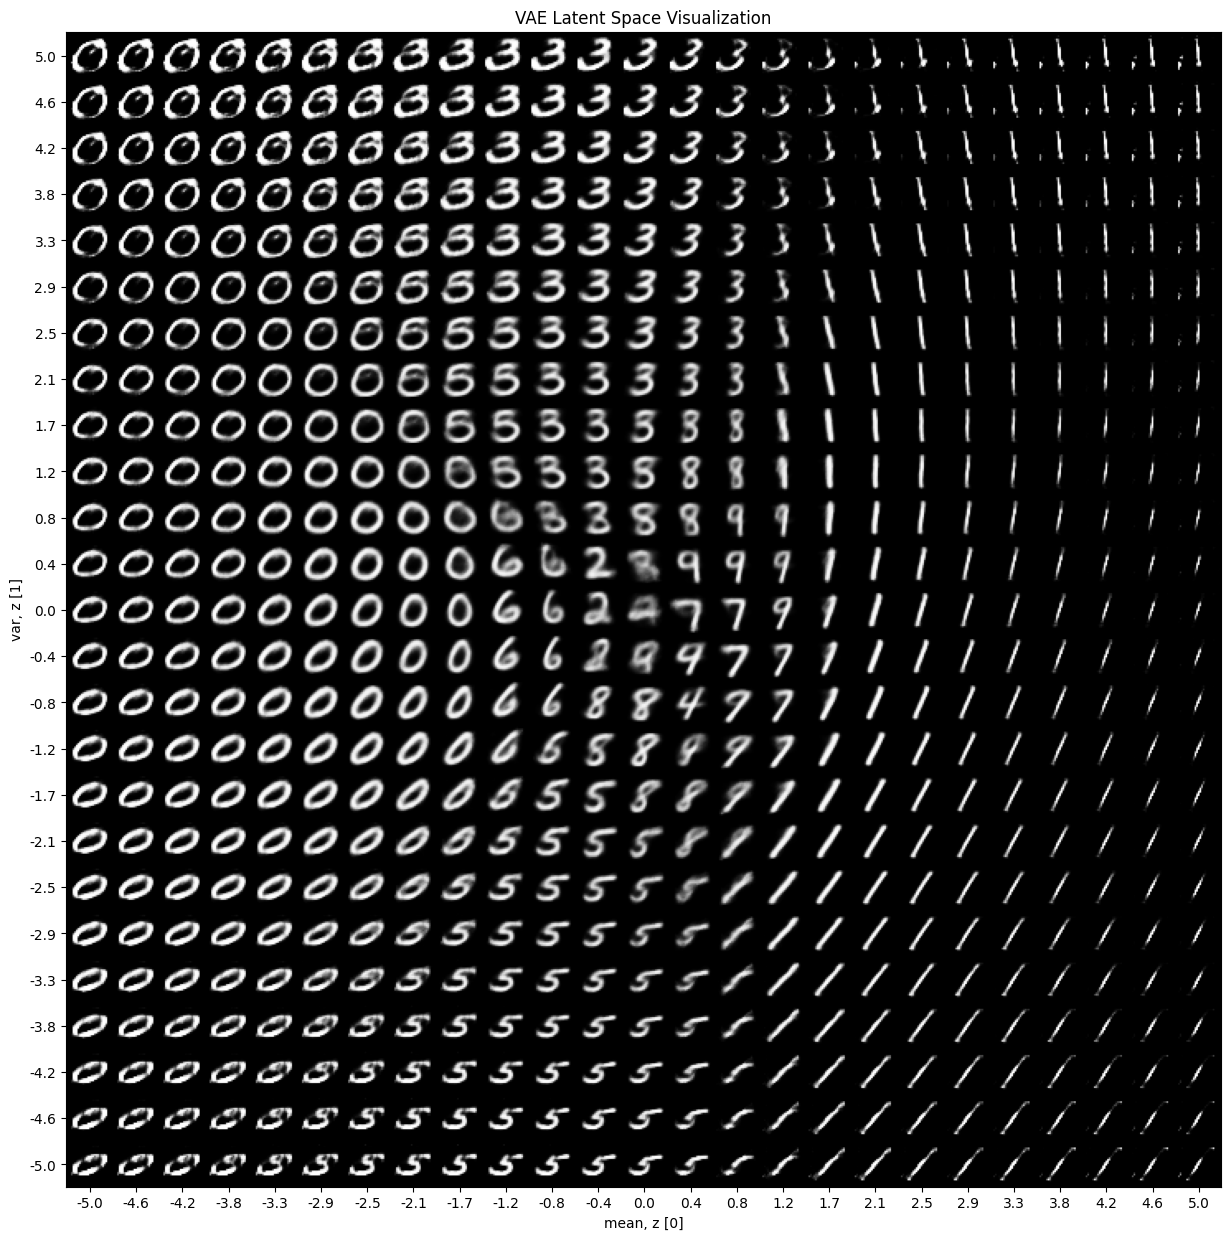

In [ ]:
# Call the plot_latent_space function to visualize the latent space with a larger scale of 5.0
# This generates a grid of digits corresponding to a wider region of the latent space, showing more diversity
plot_latent_space(model, scale=5.0)